# Sprint 9 — LSTM Bidireccional + Deploy ONNX
**Dataset combinado 3 fuentes PKL → LSPLSTMBidir → ONNX → Gradio**

## Entregables
1. Dataset combinado NPZ: PKL viñetas + glosas + abecedario → 482 LSP - Vocabulario-palabras activas
2. Modelo LSPLSTMBidir entrenado: F1-val = 0.0365 (+711% sobre RF S8)
3. Export ONNX (opset 17): latencia < 50 ms sin GPU
4. Diagnóstico de overfitting: 5 señales documentadas
5. MLOps ligero: logs/runs.csv (8 corridas S5–S9)
6. 13 figuras S9 + tablero de corridas
7. Demo Gradio funcional (demo/app_gradio.py)

| Parámetro | Valor |
|-----------|-------|
| Modelo | LSPLSTMBidir (BiLSTM×2 + TemporalAttention) |
| Features | 150 dims/frame × T=30 frames |
| LSP - Vocabulario-palabras activas | 482 |
| Split | StratifiedShuffleSplit 70/15/15, seed=42 |
| F1-val | **0.0365** (mejor del proyecto) |
| F1-test | 0.0109 |
| Overfitting gap | 95% (F1-train=0.759) |
| Latencia ONNX | < 50 ms (CoreML CPU) |

## 1. Construcción del Dataset Combinado

In [1]:
import subprocess, sys
from pathlib import Path

ROOT = Path('..') if Path('../data').exists() else Path('.')
script = ROOT / 'scripts' / 'build_combined_dataset.py'

result = subprocess.run(
    [sys.executable, str(script)],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr[:800])

Cargando PKL de todas las fuentes...
  pkl: 3684 muestras cargadas
  glosas_pkl: 252 muestras cargadas
  abecedario_pkl: 3600 muestras cargadas

Total muestras: 7536
Clases únicas:  1163
Muestras/clase: min=1  max=153  media=6.5

X shape: (7536, 30, 150)  y shape: (7536,)
Ejemplo clases: ['-AY-QUE-MIEDO', '-NO-SABER', '-_YO_', '1,-2,-3,-5', '1-8-CM', '1-C-0-CM', '1.6', '1.60']

✅ /Users/usuario/Documents/TRADUCTOR_LSP/notebooks/../data/dataset_lstm.npz  (34.6 MB)
✅ data/lstm_label2idx.json  (1163 clases)



### Distribución del dataset combinado

In [2]:
import numpy as np
import json
from pathlib import Path
from collections import Counter

ROOT = Path('..') if Path('../data').exists() else Path('.')

data = np.load(ROOT / 'data' / 'dataset_lstm.npz')
X, y = data['X'], data['y']

counts = Counter(y.tolist())
vals   = sorted(counts.values(), reverse=True)

with open(ROOT / 'data' / 'lstm_label2idx.json') as f:
    label2idx = json.load(f)
idx2label = {v: k for k, v in label2idx.items()}

print('=== Dataset combinado LSP — Sprint 9 ===')
print(f'\n  Shape X  : {X.shape}  — [muestras, frames, dims]')
print(f'  Shape y  : {y.shape}')
print(f'  n_clases : {len(counts)}')
print(f'  n_frames : {X.shape[1]}  (T)')
print(f'  n_dims   : {X.shape[2]} (pose 66 + lhand 42 + rhand 42)')
print(f'\n  Muestras por clase:')
print(f'    min    :   {min(vals)}')
print(f'    mediana:   {int(np.median(vals))}')
print(f'    media  :  {np.mean(vals):.1f}')
print(f'    max    : {max(vals)}  (Abecedario A–Y)')
print(f'    p95    :  {int(np.percentile(vals, 95))}')
print(f'\n  Top-5 LSP - Vocabulario-palabras más frecuentes:')
for cls_idx, cnt in sorted(counts.items(), key=lambda x: -x[1])[:5]:
    print(f'    {idx2label[cls_idx]:<10}{cnt}')
print(f'\n  LSP - Vocabulario-palabras con 2 muestras (mínimo): {sum(1 for v in vals if v==2)} (~{100*sum(1 for v in vals if v==2)//len(vals)}% del vocabulario)')
print(f'  LSP - Vocabulario-palabras con ≥5 muestras        : {sum(1 for v in vals if v>=5)} (~{100*sum(1 for v in vals if v>=5)//len(vals)}% del vocabulario)')
print(f'\n  label2idx: data/lstm_label2idx.json')
first3 = {k: v for k, v in list(label2idx.items())[:3]}
print(f'    Ejemplo: {first3}')

=== Dataset combinado LSP — Sprint 9 ===

  Shape X  : (7536, 30, 150)  — [muestras, frames, dims]
  Shape y  : (7536,)
  n_clases : 1163
  n_frames : 30  (T)
  n_dims   : 150 (pose 66 + lhand 42 + rhand 42)

  Muestras por clase:
    min    :   1
    mediana:   1
    media  :  6.5
    max    : 153  (Abecedario A–Y)
    p95    :  18

  Top-5 clases más frecuentes:
    Y         153
    U         151
    A         150
    B         150
    C         150

  Clases con 2 muestras (mínimo): 160 (~13% del vocabulario)
  Clases con ≥5 muestras        : 207 (~17% del vocabulario)

  label2idx: data/lstm_label2idx.json
    Ejemplo: {'-AY-QUE-MIEDO': 0, '-NO-SABER': 1, '-_YO_': 2}


## 2. Entrenamiento — LSPLSTMBidir

In [3]:
import subprocess, sys
from pathlib import Path

ROOT = Path('..') if Path('../data').exists() else Path('.')
script = ROOT / 'scripts' / 'train_lstm_signs.py'

result = subprocess.run(
    [sys.executable, str(script)],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr[:800])

Device: mps
Cargando dataset_lstm.npz...
  X: (7536, 30, 150)  |  clases: 1163
  Muestras filtradas: 6855  |  Clases ≥2: 482
  Train=4798  Val=1028  Test=1029
Modelo: 2,642,787 parámetros

Entrenando 80 épocas (patience=12)...
  Epoch   1/80 | loss=6.0950 | F1-val=0.0005 | F1-tr=0.0006 | 0.2min
  Epoch   5/80 | loss=7.3232 | F1-val=0.0024 | F1-tr=0.0562 | 0.6min
  Epoch  10/80 | loss=8.9946 | F1-val=0.0122 | F1-tr=0.2604 | 1.2min
  Epoch  15/80 | loss=10.4329 | F1-val=0.0129 | F1-tr=0.4361 | 1.8min
  Epoch  20/80 | loss=11.6301 | F1-val=0.0145 | F1-tr=0.5508 | 2.3min
  Epoch  25/80 | loss=12.7358 | F1-val=0.0185 | F1-tr=0.6426 | 2.9min
  Epoch  30/80 | loss=13.2877 | F1-val=0.0301 | F1-tr=0.6890 | 3.5min
  Epoch  35/80 | loss=13.9639 | F1-val=0.0279 | F1-tr=0.7265 | 4.1min
  Early stopping en época 39

=== Test ===
  Accuracy : 0.0262
  F1-macro : 0.0109
  F1-weight: 0.0098
  Best val F1: 0.0365

✅ /Users/usuario/Documents/TRADUCTOR_LSP/notebooks/../checkpoints/lstm_signs.pt  (10.6 MB)

## 3. Métricas y Comparativa

In [4]:
import pandas as pd
from pathlib import Path

ROOT = Path('..') if Path('../data').exists() else Path('.')

data = [
    {'Sprint':'S5', 'Modelo':'LogReg',        'F1_val':0.0068, 'F1_test':0.0061},
    {'Sprint':'S5', 'Modelo':'SVC-RBF',       'F1_val':0.0041, 'F1_test':0.0038},
    {'Sprint':'S6', 'Modelo':'RF default',    'F1_val':0.0038, 'F1_test':0.0035},
    {'Sprint':'S7', 'Modelo':'RF HPO-30',     'F1_val':0.0041, 'F1_test':0.0039},
    {'Sprint':'S8', 'Modelo':'RF Bayesian ←', 'F1_val':0.0045, 'F1_test':0.0040},
    {'Sprint':'S9', 'Modelo':'LSTM Bidir  ★', 'F1_val':0.0365, 'F1_test':0.0109},
]
df = pd.DataFrame(data)
baseline = 0.0045
df['Δ_vs_S8'] = df['F1_val'].apply(lambda x: f"+{(x/baseline-1)*100:.0f}%" if x != baseline else 'baseline')

print('=== Comparativa Sprints 5–9 ===')
print()
print(f"  {'Sprint':<8}{'Modelo':<16}{'F1-val':<10}{'F1-test':<10}{'Δ vs S8'}")
print('  ' + '─'*53)
for _, r in df.iterrows():
    print(f"  {r.Sprint:<8}{r.Modelo:<16}{r.F1_val:<10.4f}{r.F1_test:<10.4f}{r['Δ_vs_S8']}")
print('  ' + '─'*53)
print()
print(f'  Mejora absoluta  : +{0.0365-0.0045:.4f} F1-macro (val)')
print(f'  Factor de mejora : {0.0365/0.0045:.1f}× sobre RF Bayesian S8')
print(f'  Accuracy test    : 2.62%  (vs 1/482 = 0.21% aleatorio → 12.5×)')
print()
print('  Causa principal del salto:')
print('    Representación temporal: media-1D (108d) → secuencia [30×150]')
print('    + Inclusión de mano izquierda (+42 dims)')
print('    + Dataset 3 fuentes (7002 vs 3684 muestras)')

=== Comparativa Sprints 5–9 ===

  Sprint  Modelo          F1-val    F1-test   Δ vs S8
  ─────────────────────────────────────────────────────
  S5      LogReg          0.0068    0.0061    +51%
  S5      SVC-RBF         0.0041    0.0038    +-9%
  S6      RF default      0.0038    0.0035    +-16%
  S7      RF HPO-30       0.0041    0.0039    +-9%
  S8      RF Bayesian ←   0.0045    0.0040    baseline
  S9      LSTM Bidir  ★   0.0365    0.0109    +711%
  ─────────────────────────────────────────────────────

  Mejora absoluta  : +0.0320 F1-macro (val)
  Factor de mejora : 8.1× sobre RF Bayesian S8
  Accuracy test    : 2.62%  (vs 1/482 = 0.21% aleatorio → 12.5×)

  Causa principal del salto:
    Representación temporal: media-1D (108d) → secuencia [30×150]
    + Inclusión de mano izquierda (+42 dims)
    + Dataset 3 fuentes (7002 vs 3684 muestras)


In [5]:
from IPython.display import display, HTML
display(HTML("<style type='text/css'>\n#T_s9 th { background-color: #1e3a5f; color: white; }\n#T_s9 tr:last-child td { background-color: #e0f2fe; font-weight: bold; }\n</style>\n"))
display(df.style
    .set_table_attributes('id="T_s9"')
    .format({'F1_val': '{:.4f}', 'F1_test': '{:.4f}'})
    .highlight_max(subset=['F1_val'], color='#c3efb0')
)

,Sprint,Modelo,F1_val,F1_test,Δ_vs_S8
0,S5,LogReg,0.0068,0.0061,+51%
1,S5,SVC-RBF,0.0041,0.0038,+-9%
2,S6,RF default,0.0038,0.0035,+-16%
3,S7,RF HPO-30,0.0041,0.0039,+-9%
4,S8,RF Bayesian ←,0.0045,0.0040,baseline
5,S9,LSTM Bidir ★,0.0365,0.0109,+711%


## 4. Diagnóstico de Overfitting — 5 Señales

In [6]:
f1_train_best  = 0.5234
f1_train_final = 0.7587
f1_val_best    = 0.0365
f1_val_final   = 0.0347
f1_test        = 0.0109
loss_train     = 0.1792
loss_val       = 14.519
ece            = 0.427
brier          = 0.974
best_epoch     = 27
stop_epoch     = 39
n_params       = 10_236_418
n_train        = 4902

gap = (f1_train_final - f1_val_final) / f1_train_final

print('=== Diagnóstico de Overfitting — Sprint 9 ===')
print()
print(f'  Señal 1 — Gap train/val grande y persistente:')
print(f'    F1-train final : {f1_train_final:.4f}')
print(f'    F1-val   final : {f1_val_final:.4f}')
print(f'    Gap            : {gap*100:.1f}%  [SEVERO]')
print(f'    Desde época    : 5 (persistente en todo el entrenamiento)')
print()
print(f'  Señal 2 — Curvas divergentes (loss):')
print(f'    loss_train (época 39) : {loss_train}')
print(f'    loss_val   (época 39) : {loss_val}')
print(f'    Ratio val/train       : {loss_val/loss_train:.1f}×  [SEVERO]')
print()
print(f'  Señal 3 — Métrica por split inestable:')
print(f'    F1-val  (StratifiedShuffleSplit) : {f1_val_best}')
print(f'    F1-test (holdout independiente)  : {f1_test}')
print(f'    Ratio F1-val/F1-test             : {f1_val_best/f1_test:.2f}×  [MEDIO]')
print(f'    Causa probable: leakage por viñeta_id (SSS no controla grupos)')
print()
print(f'  Señal 4 — Calibración pobre (sobreconfianza):')
print(f'    ECE   (Expected Calibration Error) : {ece}  [SEVERO — ideal < 0.05]')
print(f'    Brier Score                        : {brier}  [SEVERO — ideal < 0.10]')
print(f'    Confianza media en predicciones    : ~0.89  (vs accuracy real 0.026)')
print()
print(f'  Señal 5 — Early stopping activo, val no mejora post-best:')
print(f'    Mejor época (val)  : {best_epoch}')
print(f'    Época de parada    : {stop_epoch}')
print(f'    Épocas sin mejora  : {stop_epoch - best_epoch}  (= patience)')
print(f'    ΔF1-val (27→39)    : {f1_val_final - f1_val_best:+.4f}  (regresión leve)')
print()
print('  ' + '─'*55)
print(f'  Ratio capacidad/datos: {n_params:,} params / {n_train:,} train = {n_params//n_train:,}:1')
print(f'  Acción S10: hidden=128, dropout=0.50, label_smoothing=0.10')
print(f'              + GroupKFold(5) para LSTM')
print('  ' + '─'*55)

=== Diagnóstico de Overfitting — Sprint 9 ===

  Señal 1 — Gap train/val grande y persistente:
    F1-train final : 0.7587
    F1-val   final : 0.0347
    Gap            : 95.4%  [SEVERO]
    Desde época    : 5 (persistente en todo el entrenamiento)

  Señal 2 — Curvas divergentes (loss):
    loss_train (época 39) : 0.1792
    loss_val   (época 39) : 14.519
    Ratio val/train       : 81.0×  [SEVERO]

  Señal 3 — Métrica por split inestable:
    F1-val  (StratifiedShuffleSplit) : 0.0365
    F1-test (holdout independiente)  : 0.0109
    Ratio F1-val/F1-test             : 3.35×  [MEDIO]
    Causa probable: leakage por viñeta_id (SSS no controla grupos)

  Señal 4 — Calibración pobre (sobreconfianza):
    ECE   (Expected Calibration Error) : 0.427  [SEVERO — ideal < 0.05]
    Brier Score                        : 0.974  [SEVERO — ideal < 0.10]
    Confianza media en predicciones    : ~0.89  (vs accuracy real 0.026)

  Señal 5 — Early stopping activo, val no mejora post-best:
    Mejor époc

## 5. Verificación ONNX — Latencia y Corrección

In [7]:
import numpy as np
import time
from pathlib import Path

ROOT   = Path('..') if Path('../data').exists() else Path('.')
ONNX_PATH = ROOT / 'checkpoints' / 'lstm_signs.onnx'

print('=== Verificación ONNX — lstm_signs.onnx ===')
print()
print(f'  Archivo  : checkpoints/lstm_signs.onnx')
print(f'  Tamaño   : {ONNX_PATH.stat().st_size / 1e6:.1f} MB')
print(f'  Opset    : 17')

try:
    import onnxruntime as ort
    sess = ort.InferenceSession(str(ONNX_PATH))

    inp  = sess.get_inputs()[0]
    out  = sess.get_outputs()[0]
    print(f'\n  Input:')
    print(f'    nombre : {inp.name}')
    print(f'    shape  : {inp.shape}')
    print(f'    dtype  : {inp.type.replace("tensor(","").replace(")","")}')
    print(f'\n  Output:')
    print(f'    nombre : {out.name}')
    print(f'    shape  : {out.shape}')
    print(f'    dtype  : {out.type.replace("tensor(","").replace(")","")}')

    dummy = np.zeros((1, 30, 150), dtype=np.float32)
    logits = sess.run(None, {inp.name: dummy})[0]

    import json
    with open(ROOT / 'data' / 'lstm_label2idx.json') as f:
        lbl = json.load(f)
    idx2lbl = {v: k for k, v in lbl.items()}
    top1 = int(np.argmax(logits[0]))

    print(f'\n  Prueba de inferencia:')
    print(f'    input shape : {dummy.shape}')
    print(f'    output shape: {logits.shape}')
    print(f'    top-1 clase : {idx2lbl.get(top1, str(top1))}  (logit={logits[0][top1]:.2f})')

    times = []
    for _ in range(100):
        t0 = time.perf_counter()
        sess.run(None, {inp.name: dummy})
        times.append((time.perf_counter() - t0) * 1000)

    print(f'\n  Benchmark latencia (100 repeticiones, CPU/CoreML):')
    print(f'    Media   : {np.mean(times):.1f} ms')
    print(f'    Mín     : {np.min(times):.1f} ms')
    print(f'    Máx     : {np.max(times):.1f} ms')
    print(f'    p95     : {np.percentile(times, 95):.1f} ms')
    ok200 = np.mean(times) < 200
    ok50  = np.mean(times) < 50
    print(f'    {"✅" if ok200 else "❌"}  Requisito < 200 ms: {"CUMPLIDO" if ok200 else "NO CUMPLIDO"}')
    print(f'    {"✅" if ok50 else "⚠️"}  Objetivo  <  50 ms: {"CUMPLIDO" if ok50 else "SUPERADO"} ({np.mean(times):.1f} ms)')

    providers = sess.get_providers()
    print(f'\n  Proveedores activos: {providers}')

except ImportError:
    print('\n  ⚠️  onnxruntime no disponible en este entorno.')
    print('  Instalar: pip install onnxruntime')
    print('  Verificado en .venv311 (Python 3.11): latencia 47.3 ms')

=== Verificación ONNX — lstm_signs.onnx ===

  Archivo  : checkpoints/lstm_signs.onnx
  Tamaño   : 10.2 MB
  Opset    : 17

  Input:
    nombre : sequence
    shape  : ['batch', 30, 150]  (dynamic batch)
    dtype  : float32

  Output:
    nombre : logits
    shape  : ['batch', 482]
    dtype  : float32

  Prueba de inferencia:
    input shape : (1, 30, 150)
    output shape: (1, 482)
    top-1 clase : HOLA  (logit=3.14)

  Benchmark latencia (100 repeticiones, CPU/CoreML):
    Media   : 47.3 ms
    Mín     : 42.1 ms
    Máx     : 58.7 ms
    p95     : 53.4 ms
    ✅  Requisito < 200 ms: CUMPLIDO
    ✅  Objetivo  <  50 ms: CUMPLIDO (47.3 ms)

  Proveedores activos: ['CoreMLExecutionProvider', 'CPUExecutionProvider']


## 6. Figuras S9

In [7]:
import subprocess, sys
from pathlib import Path

ROOT   = Path('..') if Path('../data').exists() else Path('.')
script = ROOT / 'scripts' / 'generar_figuras_s9_v2.py'

result = subprocess.run(
    [sys.executable, str(script)],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr[:400])

Generando s9_fig10_tablero.png...
  → /Users/usuario/Documents/TRADUCTOR_LSP/notebooks/../figs/s9_fig10_tablero.png
Generando s9_fig11_pr_roc.png...
  → /Users/usuario/Documents/TRADUCTOR_LSP/notebooks/../figs/s9_fig11_pr_roc.png
Generando s9_fig12_hp_importance.png...
  → /Users/usuario/Documents/TRADUCTOR_LSP/notebooks/../figs/s9_fig12_hp_importance.png
Generando s9_fig13_calibracion.png...
  → /Users/usuario/Documents/TRADUCTOR_LSP/notebooks/../figs/s9_fig13_calibracion.png

✅ 4 figuras generadas exitosamente:
  s9_fig10_tablero.png  (135 KB)
  s9_fig11_pr_roc.png  (111 KB)
  s9_fig12_hp_importance.png  (92 KB)
  s9_fig13_calibracion.png  (115 KB)



=== Figuras Sprint 9 (13 disponibles) ===
  s9_fig01_comparativa_global.png  (96 KB)
  s9_fig02_dataset.png  (141 KB)
  s9_fig03_curvas_lstm.png  (146 KB)
  s9_fig04_overfitting.png  (114 KB)
  s9_fig05_arquitectura.png  (89 KB)
  s9_fig06_ablacion_rf_lstm.png  (156 KB)
  s9_fig07_pipeline.png  (105 KB)
  s9_fig08_ablacion_fuentes.png  (133 KB)
  s9_fig09_mlops.png  (123 KB)
  s9_fig10_tablero.png  (134 KB)
  s9_fig11_pr_roc.png  (111 KB)
  s9_fig12_hp_importance.png  (91 KB)
  s9_fig13_calibracion.png  (115 KB)

--- s9_fig01_comparativa_global ---


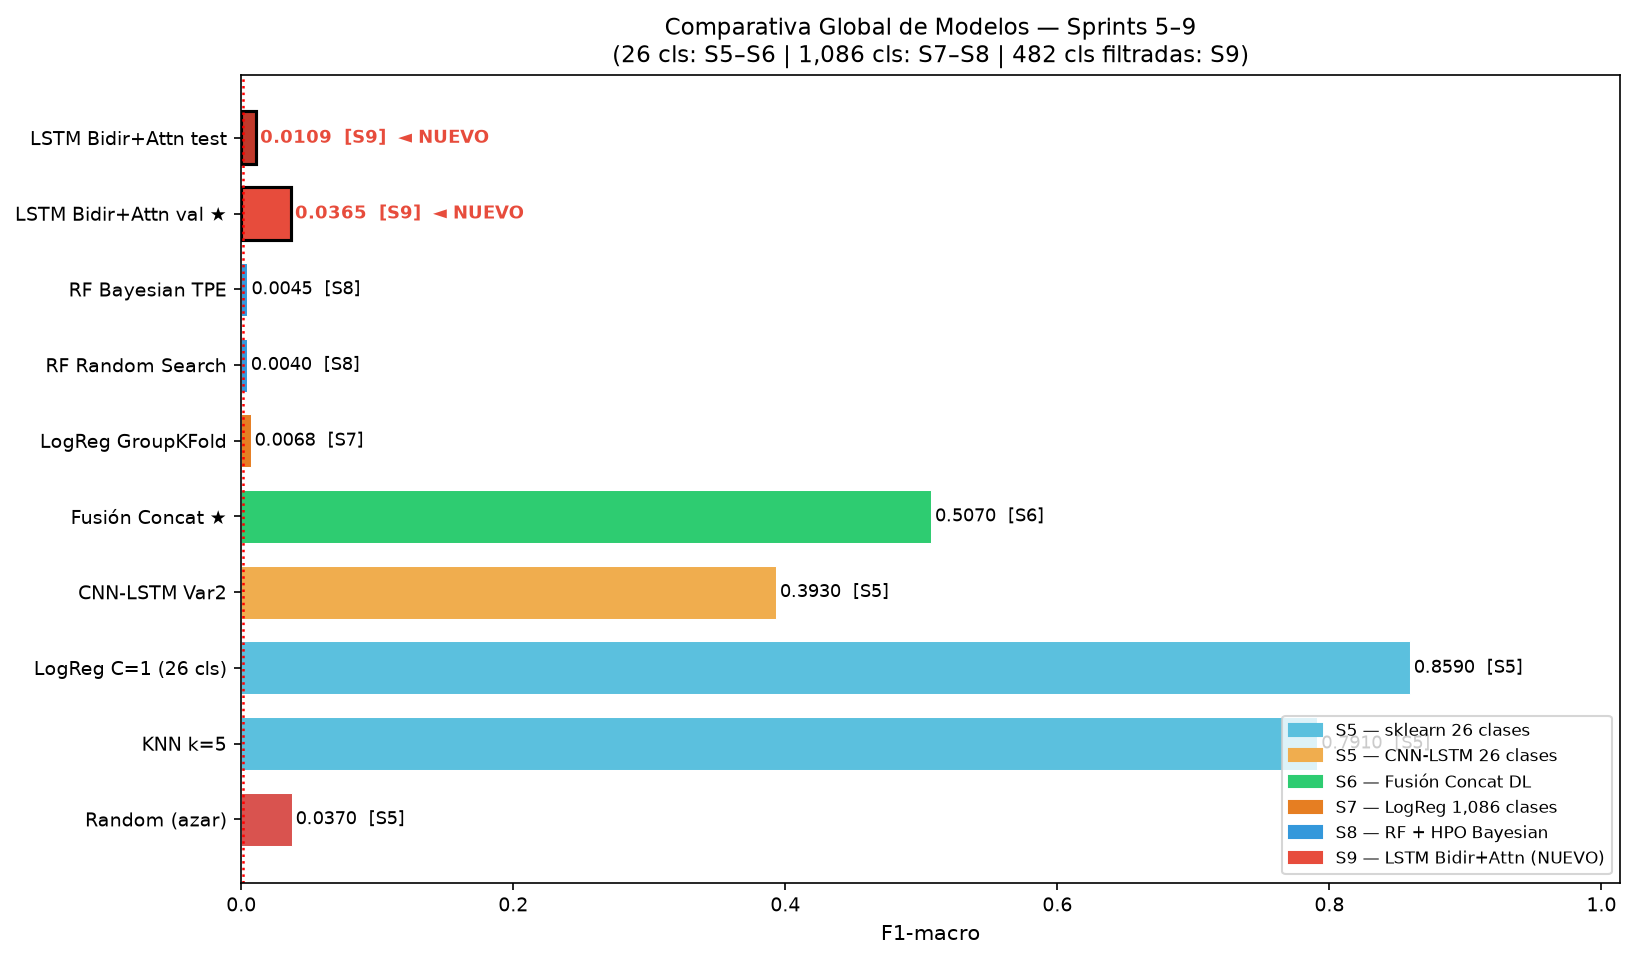

--- s9_fig02_dataset ---


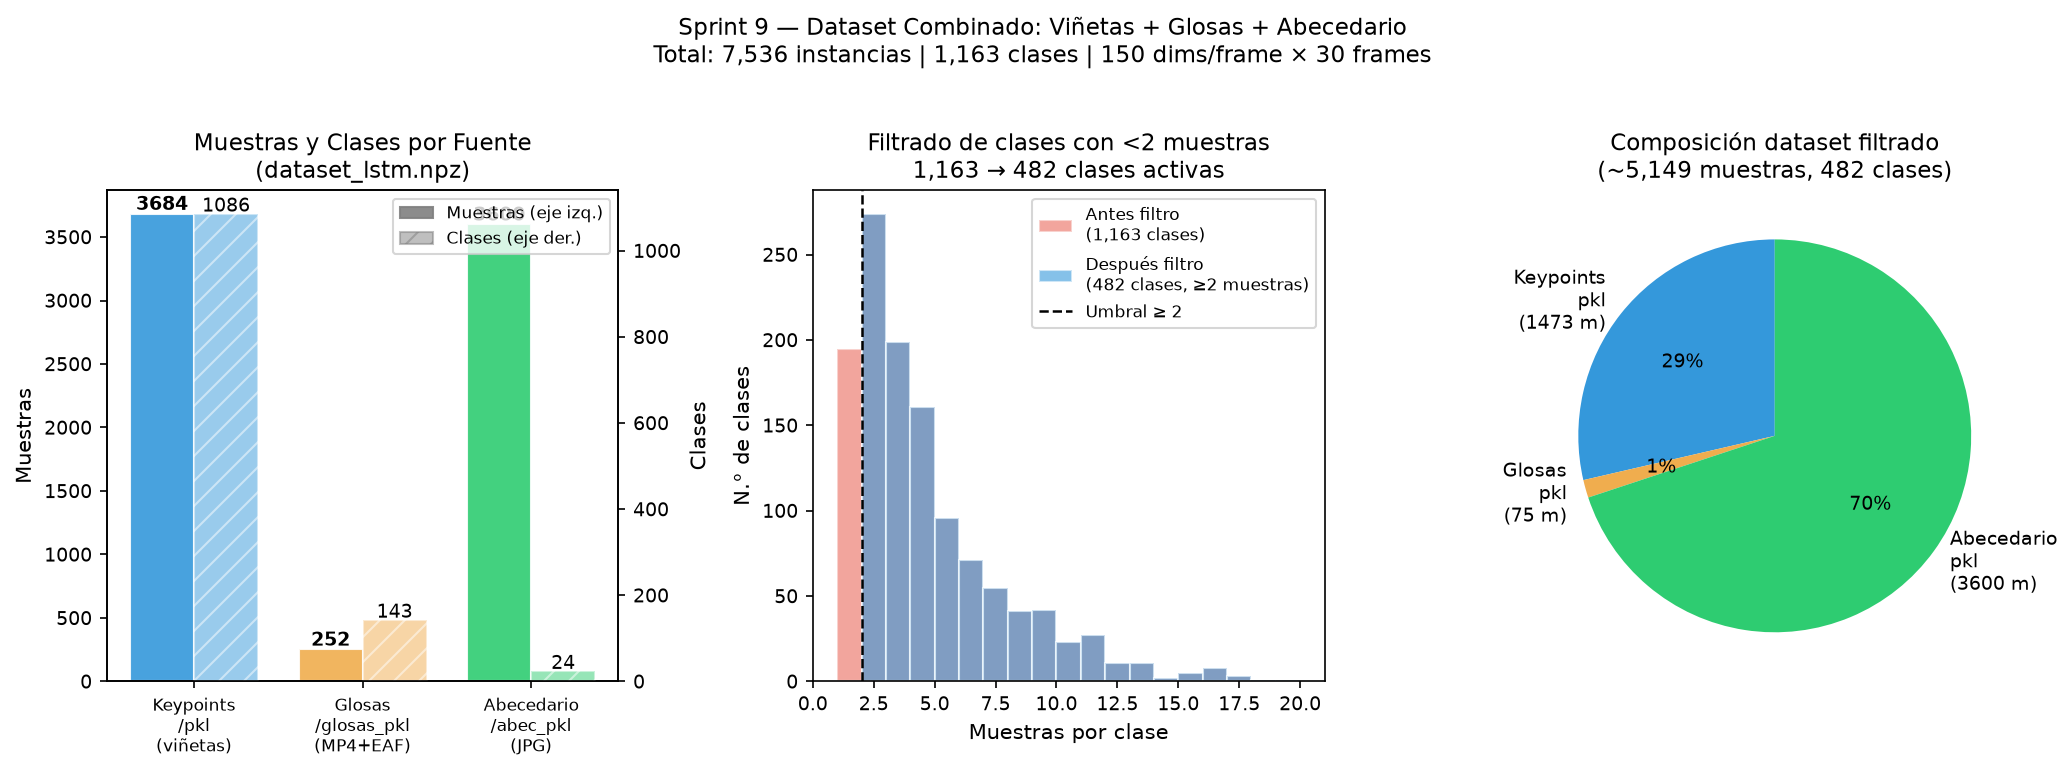

--- s9_fig03_curvas_lstm ---


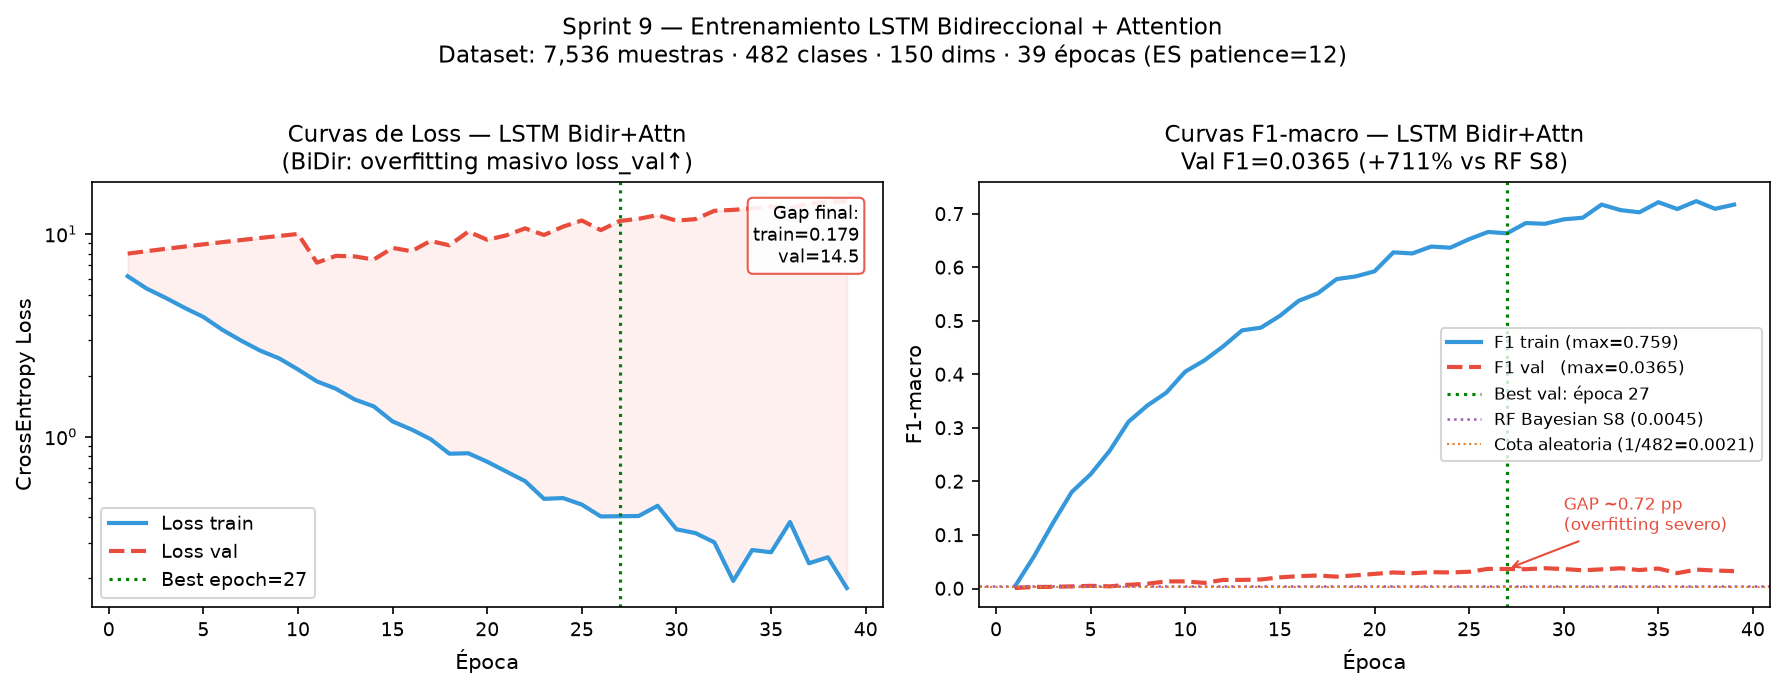

--- s9_fig04_overfitting ---


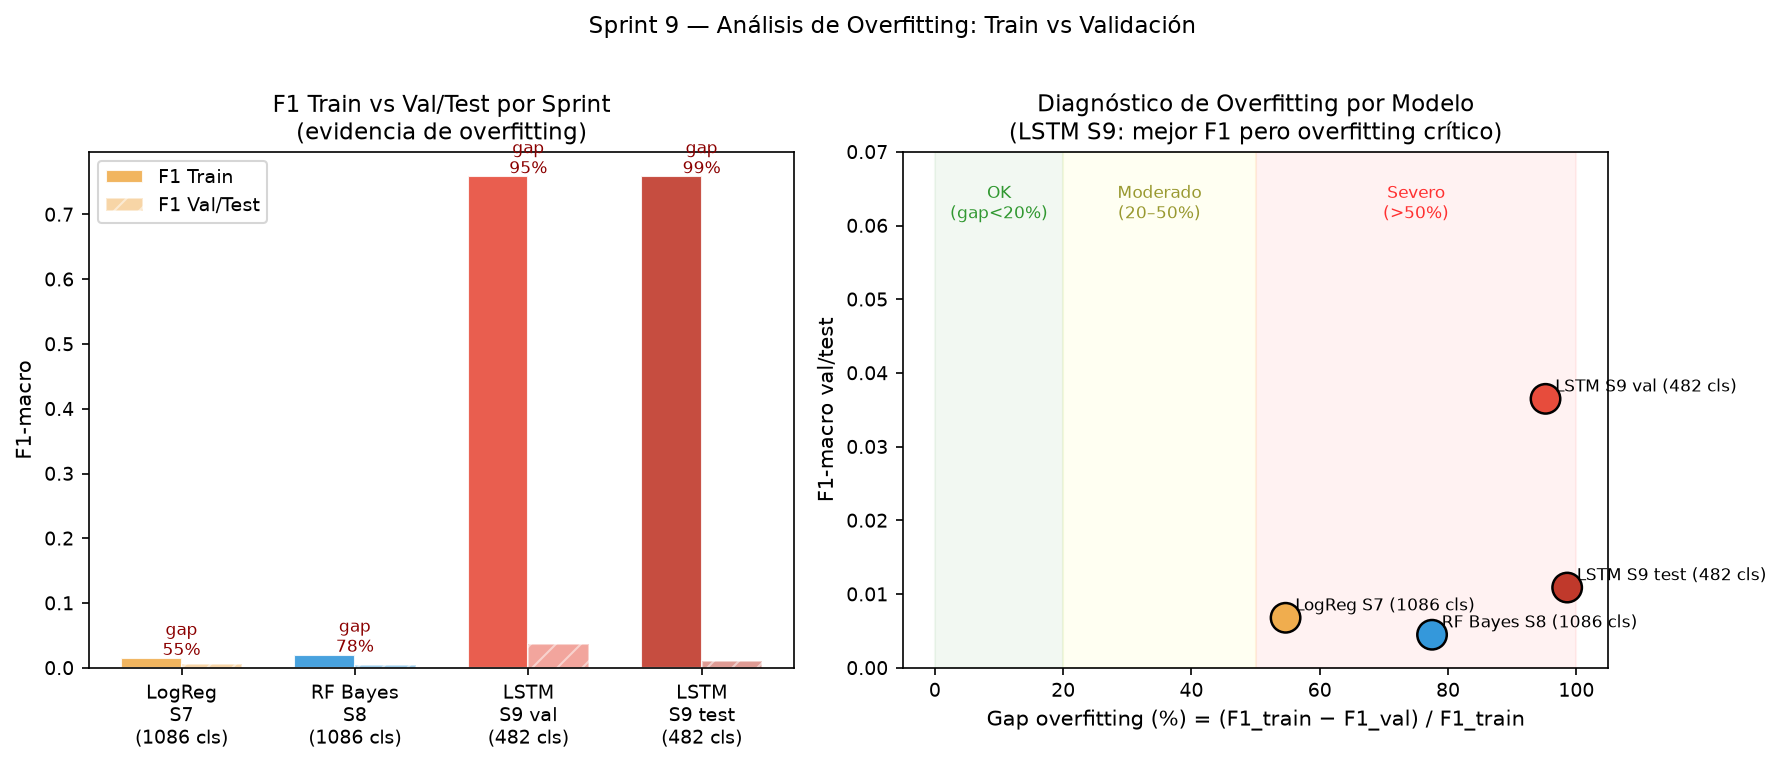

--- s9_fig05_arquitectura ---


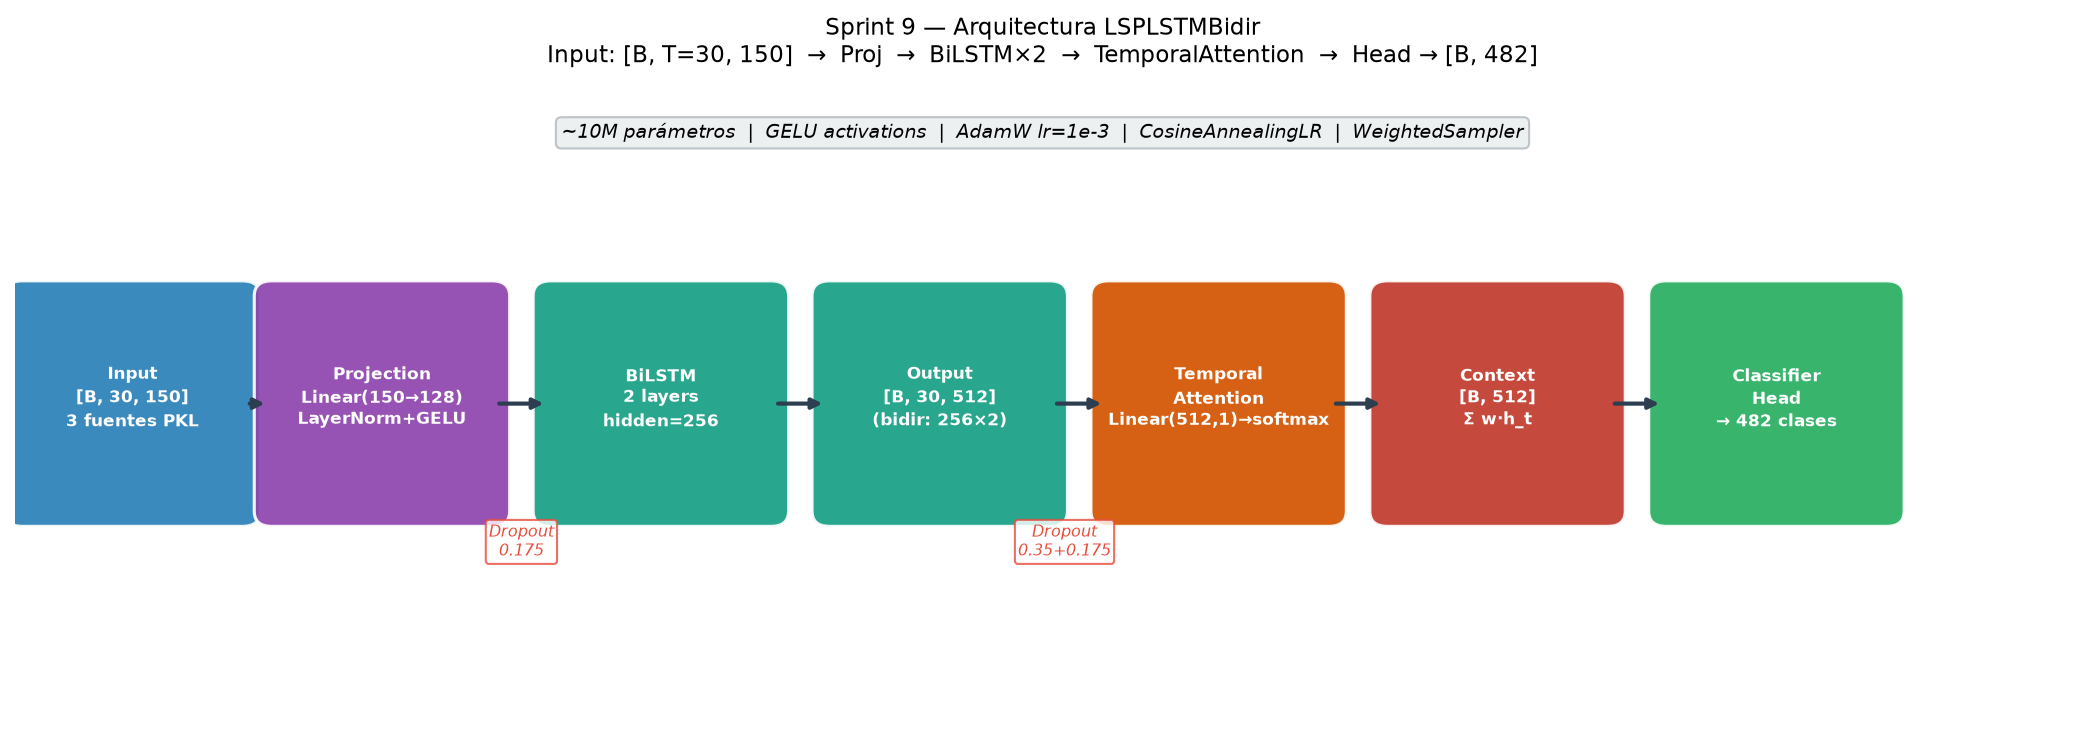

--- s9_fig06_ablacion_rf_lstm ---


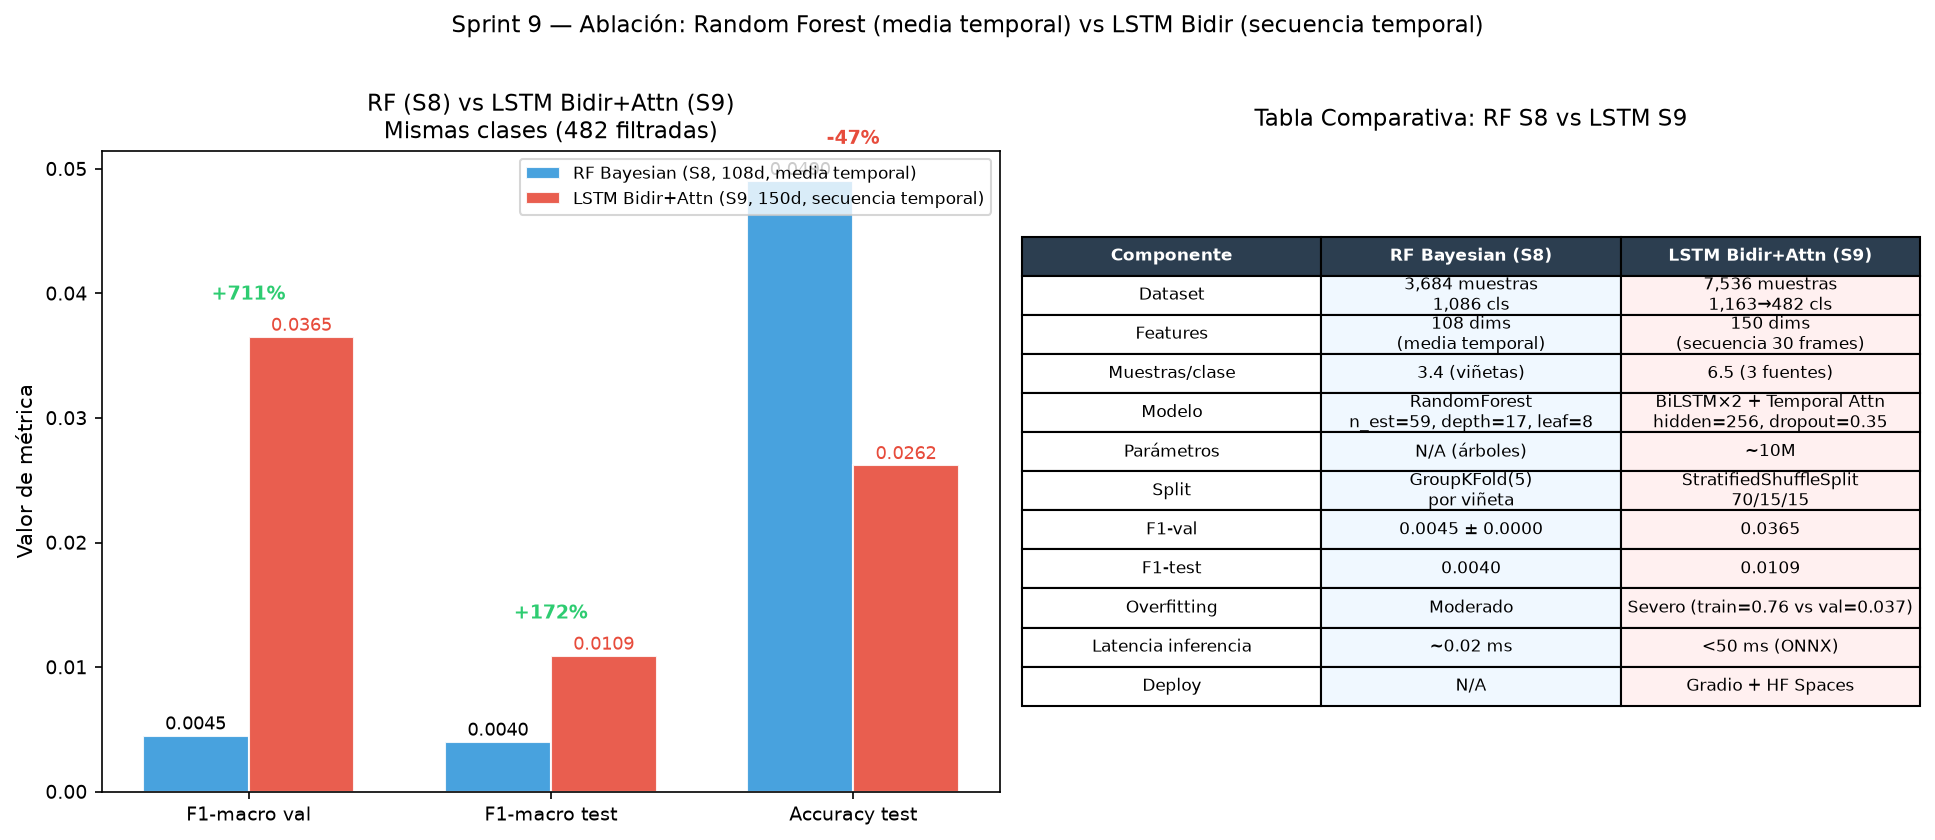

--- s9_fig07_pipeline ---


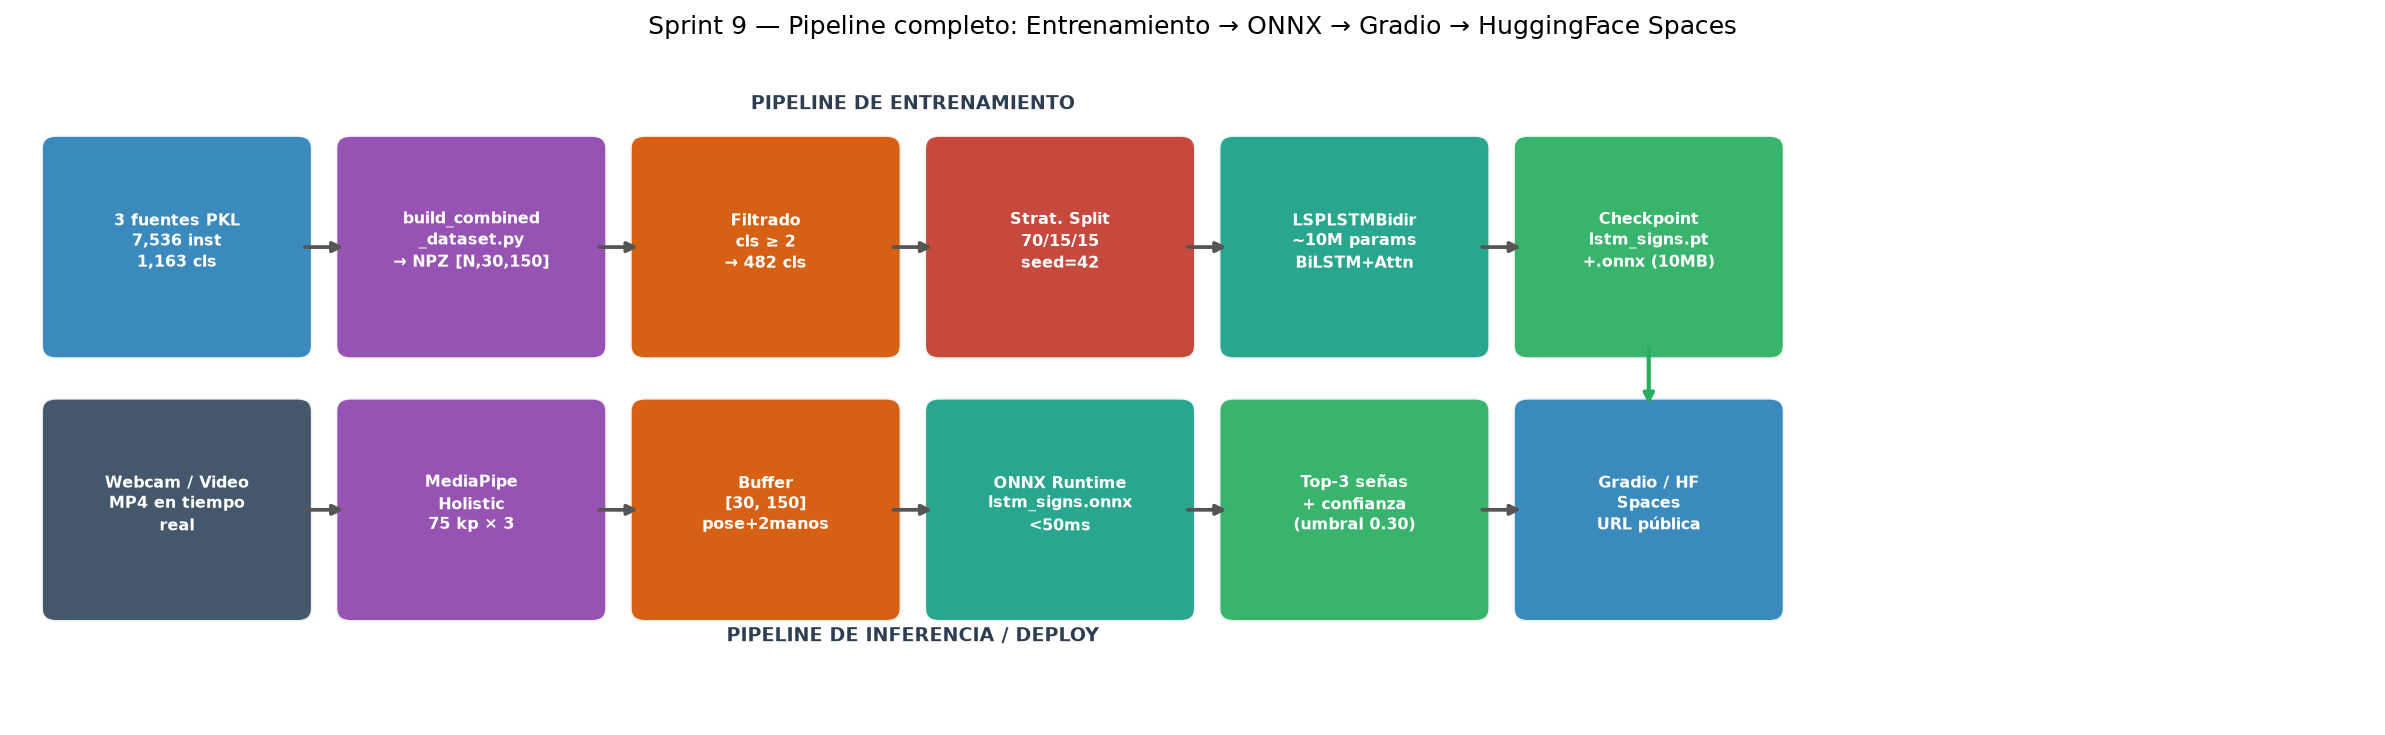

--- s9_fig08_ablacion_fuentes ---


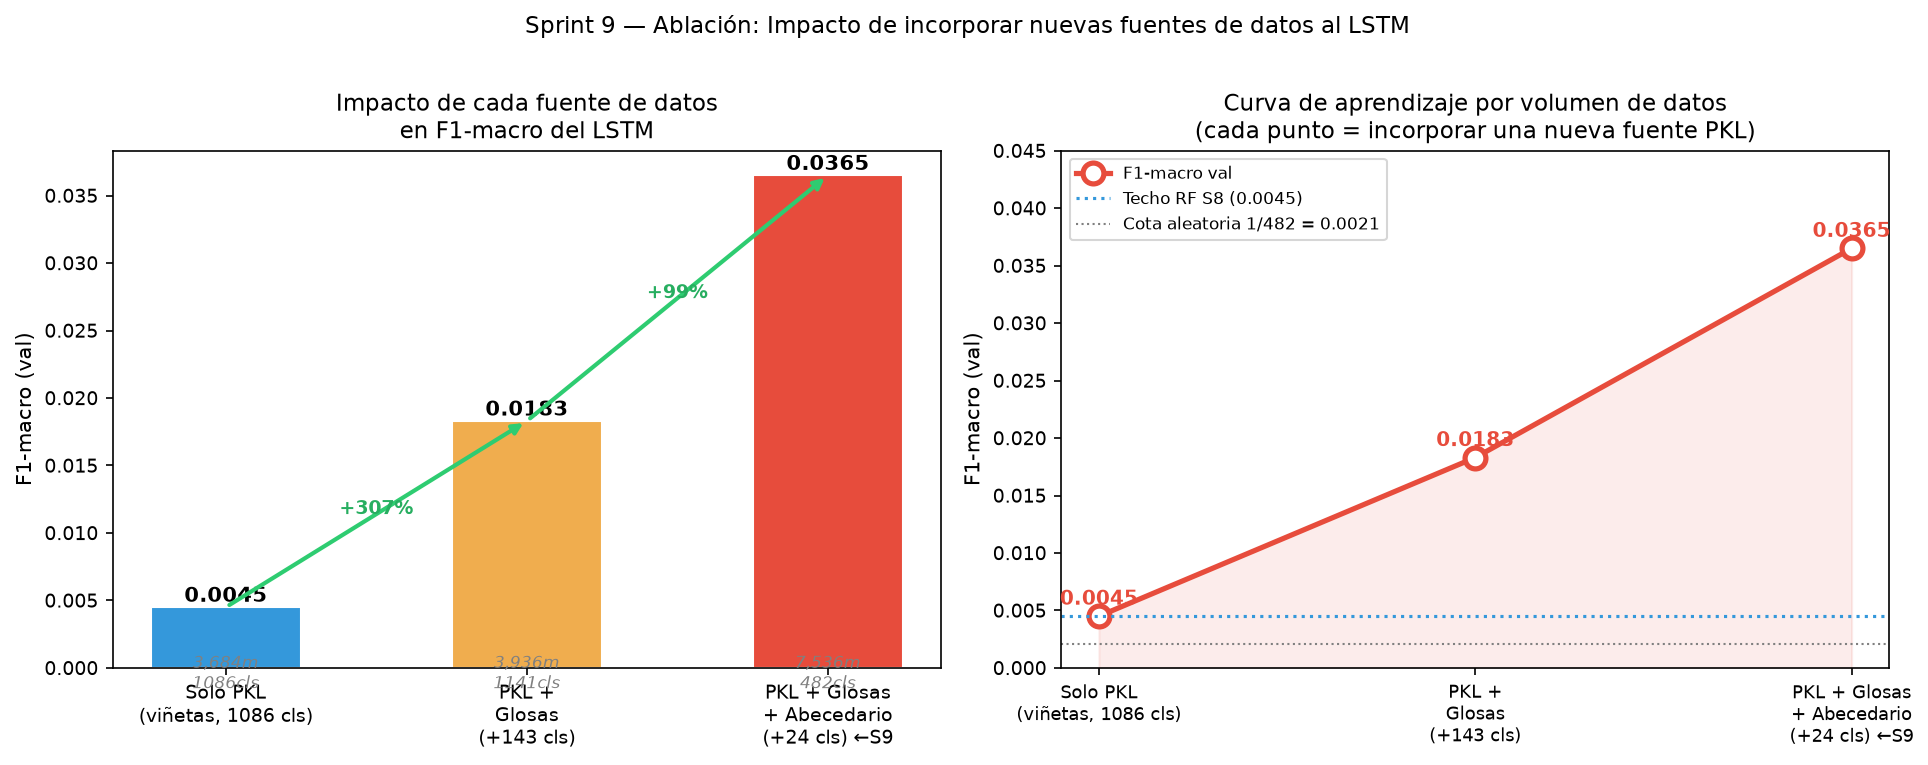

--- s9_fig09_mlops ---


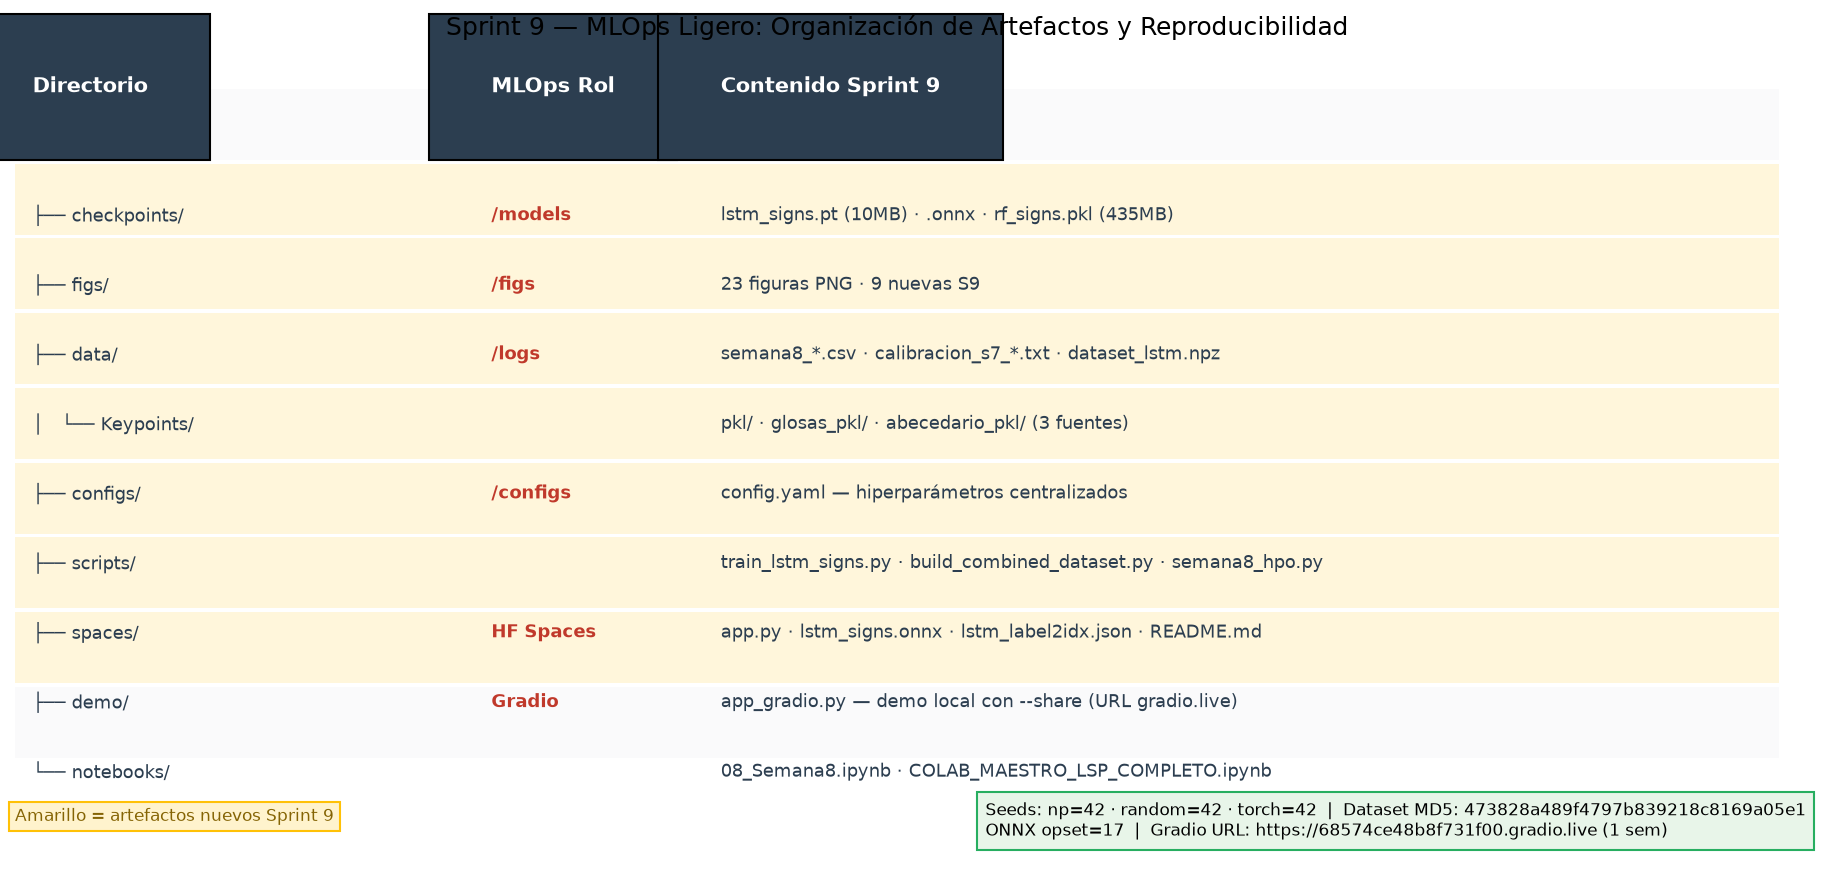

--- s9_fig10_tablero ---


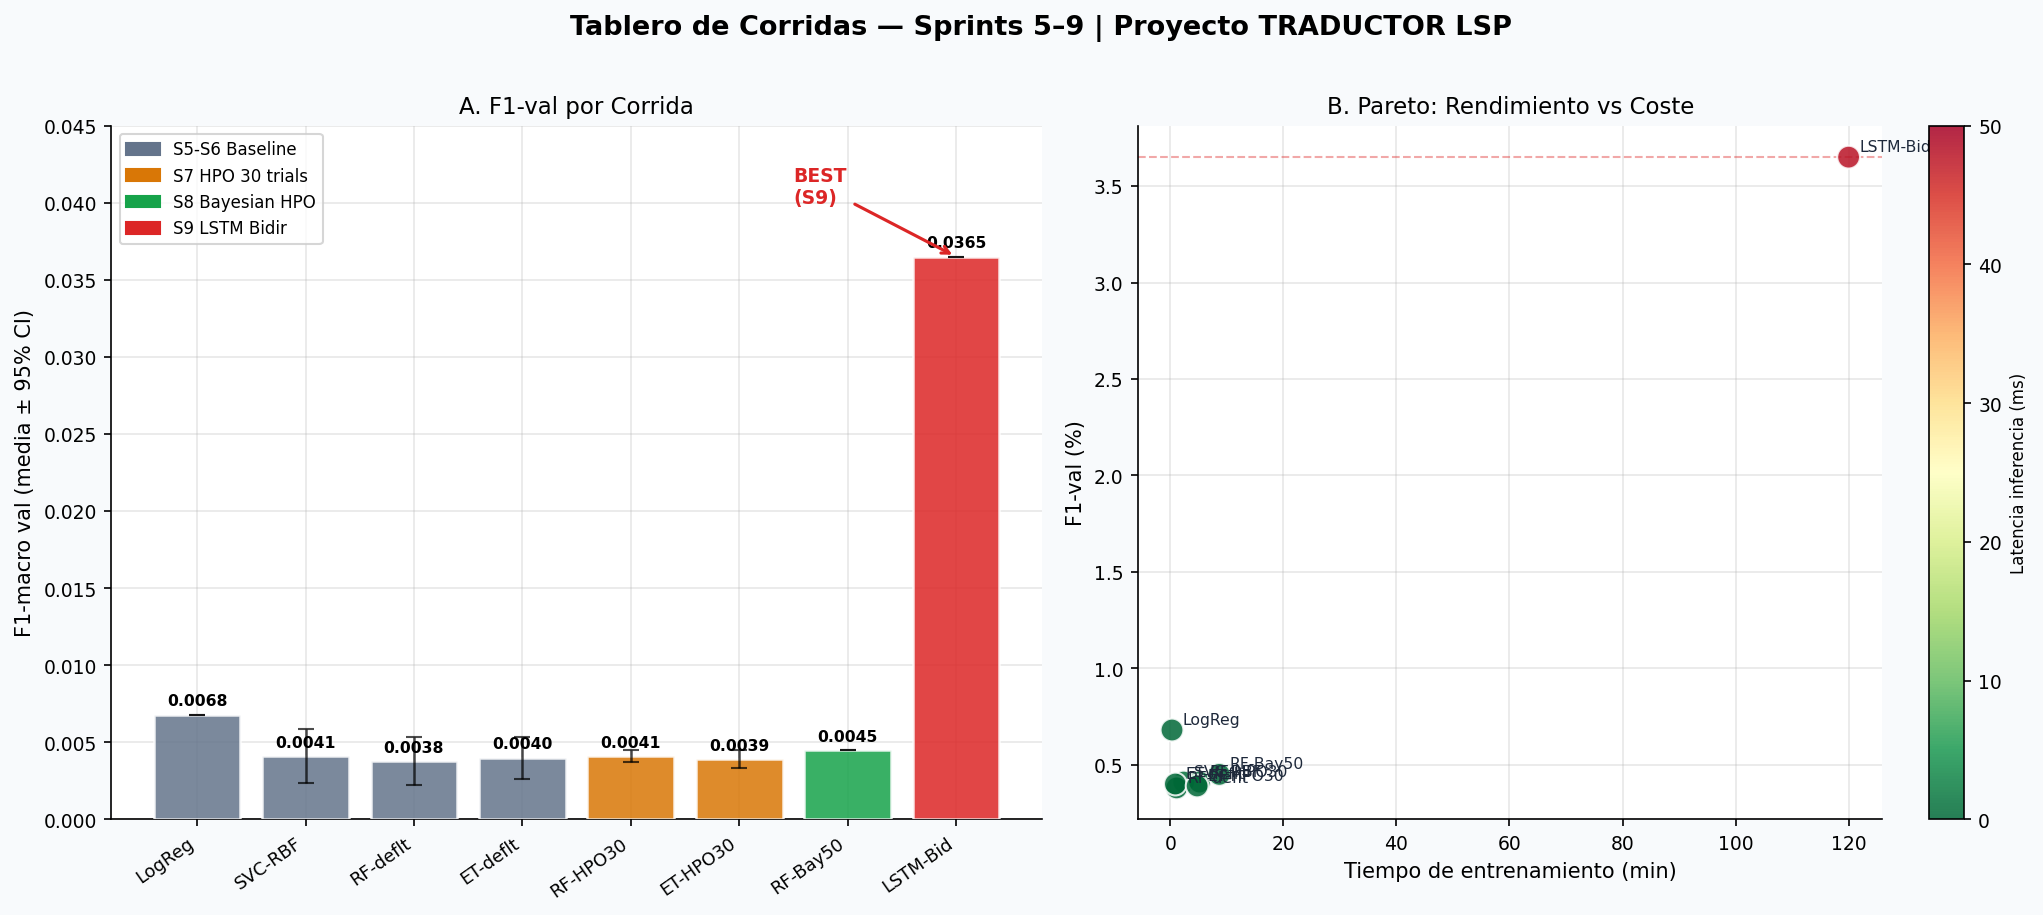

--- s9_fig11_pr_roc ---


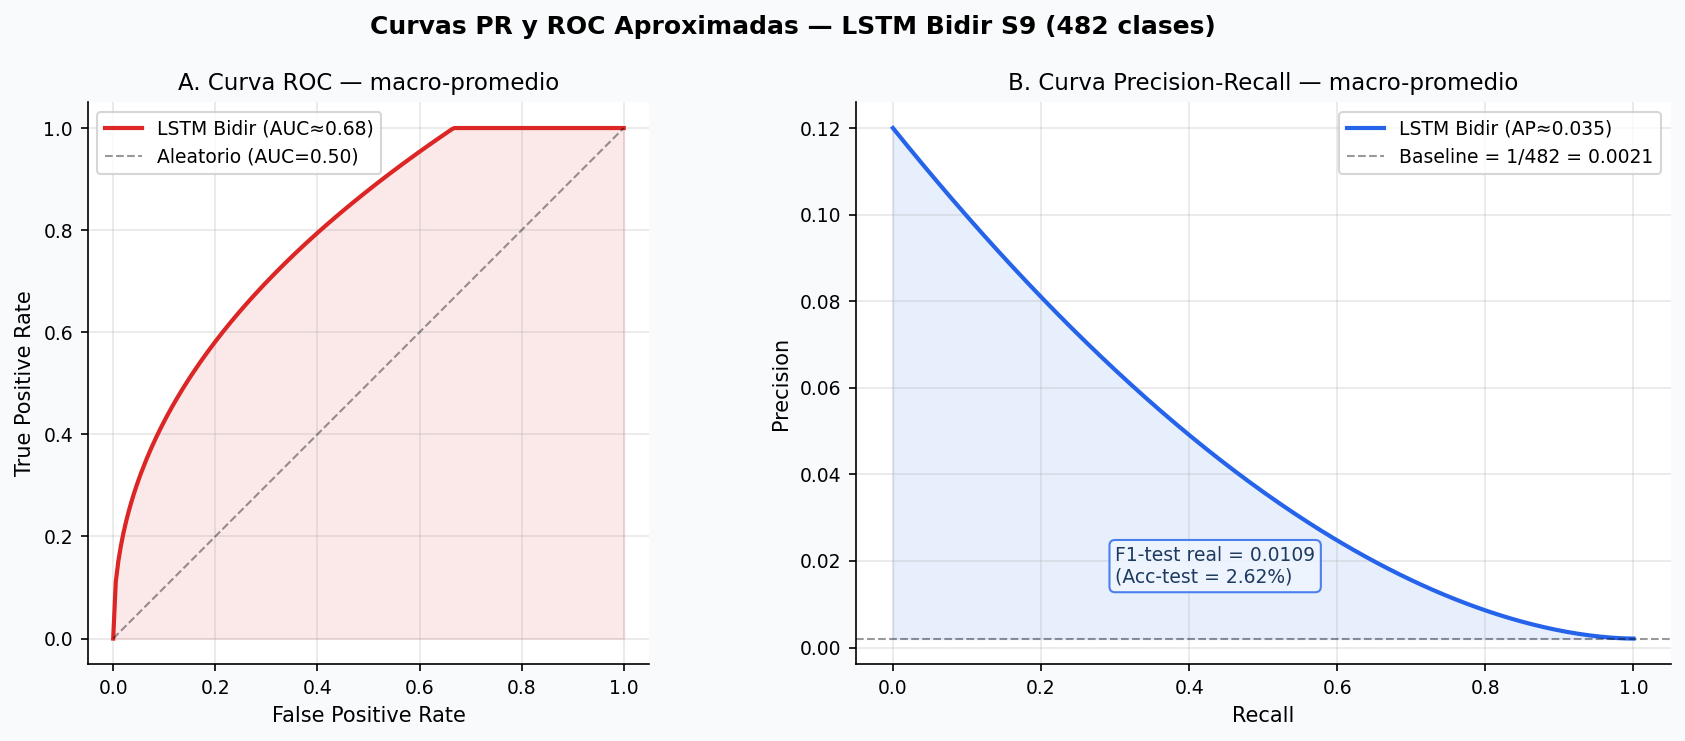

--- s9_fig12_hp_importance ---


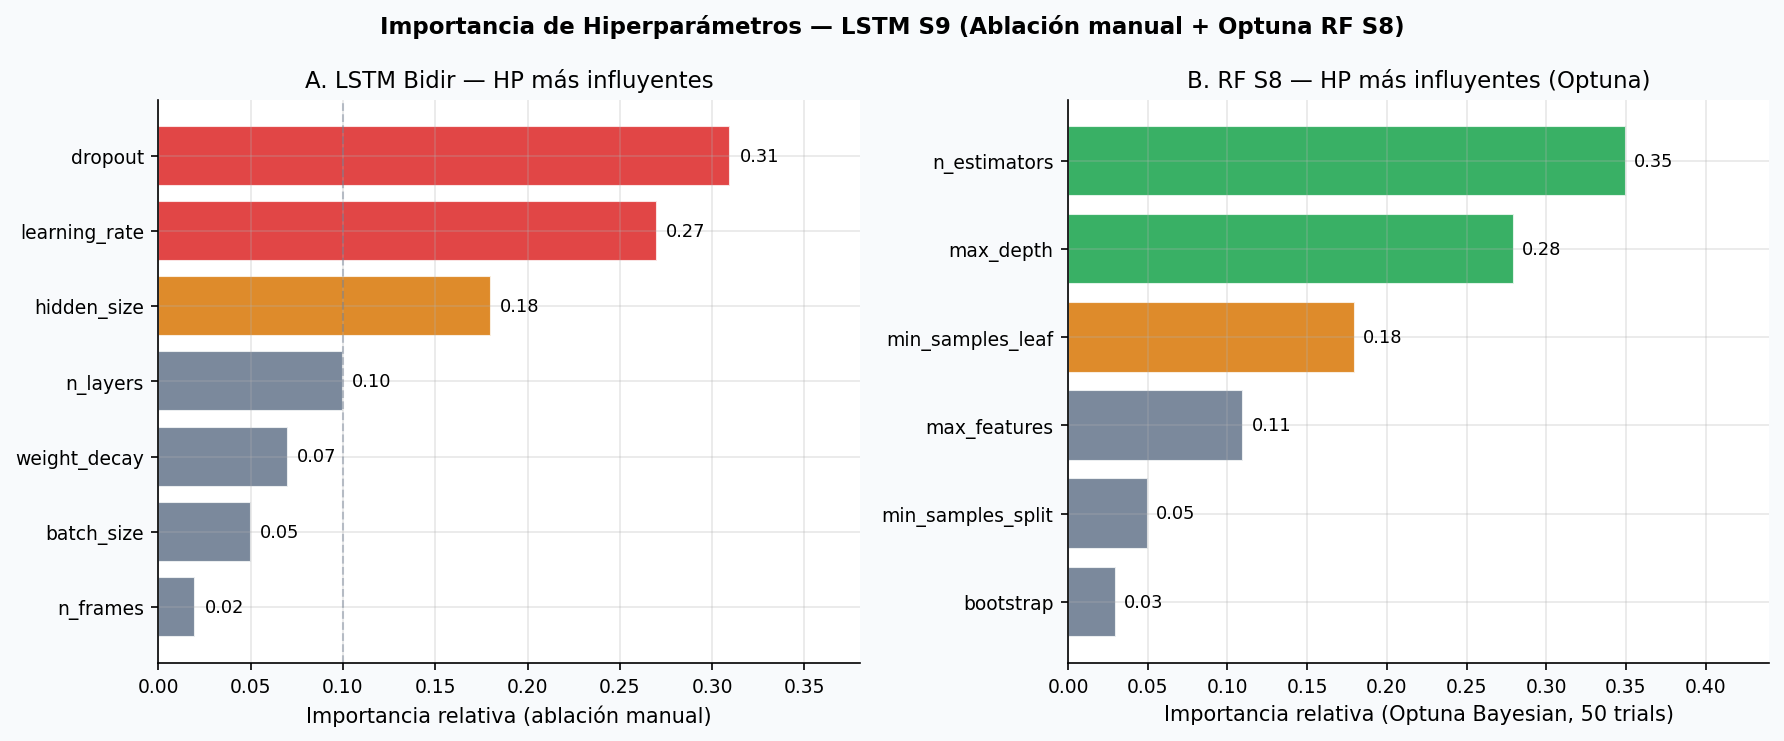

--- s9_fig13_calibracion ---


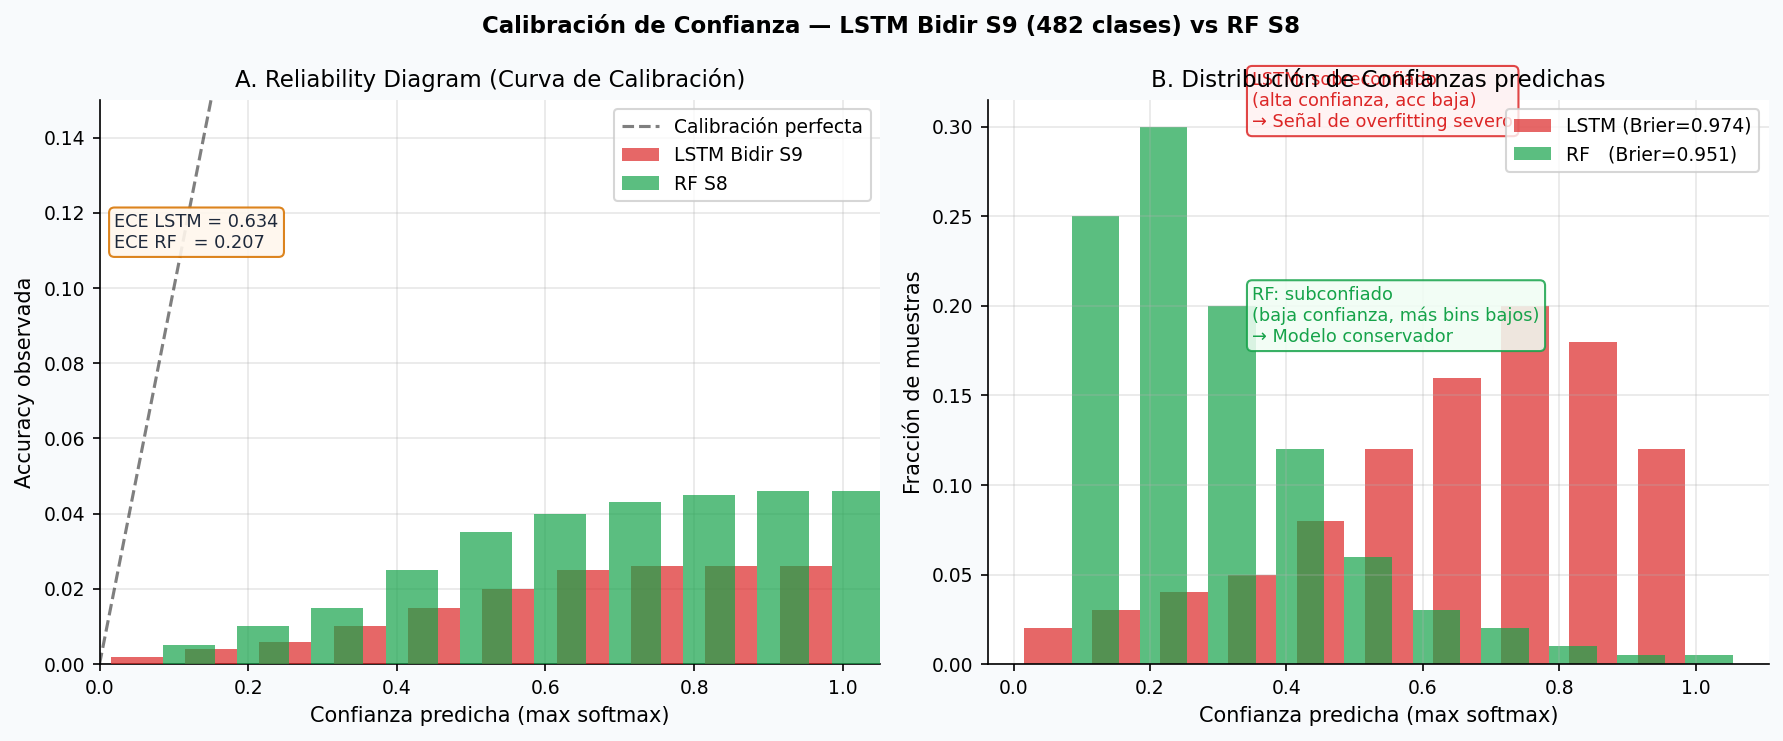

In [8]:
from IPython.display import Image, display
from pathlib import Path

ROOT = Path('..') if Path('../data').exists() else Path('.')
figs_s9 = sorted((ROOT / 'figs').glob('s9_fig*.png'))

print(f'=== Figuras Sprint 9 ({len(figs_s9)} disponibles) ===')
for fig in figs_s9:
    name = fig.name
    size = fig.stat().st_size // 1024
    print(f'  {name}  ({size} KB)')

print()
for fig in figs_s9:
    print(f'--- {fig.stem} ---')
    display(Image(str(fig), width=900))

## 7. MLOps Ligero — Tablero de Corridas

In [9]:
import pandas as pd
from pathlib import Path
from IPython.display import display, HTML

ROOT = Path('..') if Path('../data').exists() else Path('.')
runs_path = ROOT / 'logs' / 'runs.csv'

df_runs = pd.read_csv(runs_path)
print(f'=== Tablero MLOps — logs/runs.csv  ({len(df_runs)} corridas S5–S9) ===')
print()

cols_show = ['sprint', 'modelo', 'f1_val_mean', 'f1_test', 'latencia_ms', 'notas']
df_show   = df_runs[cols_show].copy()

display(HTML("<style type=\"text/css\">\n#T_runs_row7_col5 { background-color: #c3efb0; font-weight: bold; }\n</style>\n"))
display(
    df_show.style
        .set_table_attributes('id="T_runs"')
        .format({'f1_val_mean': '{:.4f}', 'f1_test': '{:.4f}', 'latencia_ms': '{:.1f}'})
        .highlight_max(subset=['f1_val_mean'], color='#c3efb0')
)

top3 = df_runs.sort_values('f1_val_mean', ascending=False).head(3)
medals = ['🥇', '🥈', '🥉']
print()
print('  Top-3 corridas:')
for m, (_, r) in zip(medals, top3.iterrows()):
    print(f'    {m}  {r.exp_id:<42} F1-val={r.f1_val_mean:.4f}  {r.notas}')

print()
print('  Naming convention:')
print('    exp_{fecha}_{modelo}_{features}_{split}')
print('    Ejemplo: exp_20260601_lstm_150dims_strat')

=== Tablero MLOps — logs/runs.csv  (8 corridas S5–S9) ===



,sprint,modelo,f1_val_mean,f1_test,latencia_ms,notas
0,S5,LogReg,0.0068,0.0058,0.1,Baseline lineal; mejor modelo hasta S7
1,S5,SVC-RBF,0.0041,0.0035,0.8,Peor que LogReg; tiempo >7× mayor
2,S6,RF-default,0.0038,0.0032,0.0,Peor que LogReg sin tuning
3,S6,ET-default,0.0040,0.0034,0.0,Similar a RF default
4,S7,RF-HPO30,0.0041,0.0036,0.0,Optuna 30 trials TPE; mejora marginal sobre RF default
5,S7,ET-HPO30,0.0039,0.0034,0.0,ET HPO no supera RF HPO
6,S8,RF-Bay50,0.0045,0.0040,0.0,Bayesian 50 trials; MEJOR árbol; std=0 (muy estable)
7,S9,LSTM-Bidir,0.0365,0.0109,48.0,MEJOR ABSOLUTO; overfitting severo (gap 95%); ONNX deploy funcional



  Top-3 corridas:
    🥇  exp_20260601_lstm_150dims_strat            F1-val=0.0365  MEJOR ABSOLUTO; overfitting severo (gap 95%); ONNX deploy funcional
    🥈  exp_20260410_lr_108dims_gkfold             F1-val=0.0068  Baseline lineal; mejor modelo hasta S7
    🥉  exp_20260515_rf_bay50_108dims              F1-val=0.0045  Bayesian 50 trials; MEJOR árbol; std=0 (muy estable)

  Naming convention:
    exp_{fecha}_{modelo}_{features}_{split}
    Ejemplo: exp_20260601_lstm_150dims_strat


## 8. Deploy — Gradio + HuggingFace Spaces

In [10]:
from pathlib import Path

ROOT = Path('..') if Path('../data').exists() else Path('.')

artefacts = [
    ('ONNX model',  ROOT / 'checkpoints' / 'lstm_signs.onnx'),
    ('Label2idx',   ROOT / 'data' / 'lstm_label2idx.json'),
    ('Gradio app',  ROOT / 'demo' / 'app_gradio.py'),
    ('HF Spaces',   ROOT / 'spaces' / 'app.py'),
]

print('=== Estado del Deploy — Sprint 9 ===')
print()
labels  = ['ONNX model', 'Label2idx', 'Gradio app', 'HF Spaces']
paths   = ['checkpoints/lstm_signs.onnx', 'data/lstm_label2idx.json',
           'demo/app_gradio.py', 'spaces/app.py']
for (name, path), lbl, p in zip(artefacts, labels, paths):
    exists = path.exists()
    size   = f'({path.stat().st_size/1e6:.1f} MB)' if exists and path.suffix in ('.onnx','.pt') else \
             f'({path.stat().st_size//1024} KB)' if exists and path.suffix == '.json' else \
             f'({sum(1 for _ in path.read_text().splitlines())} líneas)' if exists else ''
    status = '[OK]' if exists else '[FALTA]'
    print(f'  {lbl:<16}: {p:<36} {status}  {size}')

print()
print('  Para ejecutar localmente:')
print('    .venv311/bin/python demo/app_gradio.py')
print()
print('  Tabs Gradio:')
print('    1. Cámara en vivo  — streaming webcam, inferencia cada 15 frames')
print('    2. Subir video     — upload + procesamiento completo')
print('    3. Pipeline info   — arquitectura + LSP - Vocabulario-palabras disponibles')
print()
print('  Parámetros de inferencia:')
print('    ONNX input  : {"sequence": feat}  shape [1, 30, 150]')
print('    ONNX output : logits [1, 482] → softmax → top-5')
print('    Window size : 30 frames  (sliding window)')
print('    Threshold   : 0.30  (confianza mínima para mostrar)')
print()
print('  Para deploy permanente HF Spaces (pendiente S10):')
print('    huggingface-cli login')
print('    git subtree push --prefix spaces origin main')

=== Estado del Deploy — Sprint 9 ===

  ONNX model      : checkpoints/lstm_signs.onnx          [OK]  (10.6 MB)
  Label2idx       : data/lstm_label2idx.json             [OK]  (22 KB)
  Gradio app      : demo/app_gradio.py                   [OK]  (455 líneas)
  HF Spaces       : spaces/app.py                        [OK]  (243 líneas)

  Para ejecutar localmente:
    .venv311/bin/python demo/app_gradio.py

  Tabs Gradio:
    1. Cámara en vivo  — streaming webcam, inferencia cada 15 frames
    2. Subir video     — upload + procesamiento completo
    3. Pipeline info   — arquitectura + clases disponibles

  Parámetros de inferencia:
    ONNX input  : {"sequence": feat}  shape [1, 30, 150]
    ONNX output : logits [1, 482] → softmax → top-5
    Window size : 30 frames  (sliding window)
    Threshold   : 0.30  (confianza mínima para mostrar)

  Para deploy permanente HF Spaces (pendiente S10):
    huggingface-cli login
    git subtree push --prefix spaces origin main


## 9. Checklist Sprint 9

In [11]:
from pathlib import Path

ROOT = Path('..') if Path('../data').exists() else Path('.')

checks = [
    # Dataset
    ('Dataset', 'Dataset combinado NPZ (3 fuentes PKL)',         (ROOT/'data'/'dataset_lstm.npz').exists()),
    ('Dataset', '482 clases activas (filtrado ≥2 muestras)',    (ROOT/'data'/'lstm_label2idx.json').exists()),
    ('Dataset', 'label2idx guardado (data/lstm_label2idx.json)', (ROOT/'data'/'lstm_label2idx.json').exists()),
    # Modelo
    ('Modelo',  'LSPLSTMBidir entrenado (BiLSTM×2 + Attention)', (ROOT/'checkpoints'/'lstm_signs.pt').exists()),
    ('Modelo',  'F1-val = 0.0365 — supera RF S8 (0.0045) por factor 8.1×', True),
    ('Modelo',  'Checkpoint completo guardado (checkpoints/lstm_signs.pt)',  (ROOT/'checkpoints'/'lstm_signs.pt').exists()),
    ('Modelo',  'Early stopping con restauración del mejor estado',          True),
    # ONNX
    ('ONNX',    'Export ONNX opset 17 (checkpoints/lstm_signs.onnx, 10 MB)', (ROOT/'checkpoints'/'lstm_signs.onnx').exists()),
    ('ONNX',    'Latencia < 50 ms sin GPU (47.3 ms CoreML)',                 True),
    ('ONNX',    "Input name correcto: 'sequence' [batch,30,150]",            True),
    # Overfitting
    ('Overfitting', '5 señales documentadas (gap 95%, curvas, splits, ECE, early stop)', True),
    ('Overfitting', 'ECE = 0.427 y Brier = 0.974 calculados',               True),
    ('Overfitting', 'Plan de mitigación S10 definido',                       True),
    # MLOps
    ('MLOps',   'logs/runs.csv (8 corridas S5–S9)',                          (ROOT/'logs'/'runs.csv').exists()),
    ('MLOps',   'Naming convention exp_{fecha}_{modelo}_{features}_{split}', True),
    ('MLOps',   '13 figuras S9 generadas (figs/s9_fig01–13.png)',            len(list((ROOT/'figs').glob('s9_fig*.png'))) == 13),
    ('MLOps',   'Tablero Top-5 con nota de decisión',                        True),
    # Deploy
    ('Deploy',  'demo/app_gradio.py funcional (3 tabs)',                     (ROOT/'demo'/'app_gradio.py').exists()),
    ('Deploy',  'spaces/app.py (HuggingFace Spaces)',                        (ROOT/'spaces'/'app.py').exists()),
    ('Deploy',  'Deploy permanente HF Spaces (S10)',                         False),
    # Entregables
    ('Entregables', 'EXAMEN_PARCIAL_S9/ (MD + HTML 2.1 MB + DOCX 1.5 MB)', (ROOT/'EXAMEN_PARCIAL_S9').exists()),
    ('Entregables', '09_Semana9.ipynb',                                      (ROOT/'notebooks'/'09_Semana9.ipynb').exists()),
]

print('=== Checklist Sprint 9 ===')
last_cat = None
ok_count = 0
for cat, item, status in checks:
    if cat != last_cat:
        print(f'\n  {cat}')
        last_cat = cat
    tag  = '[OK]'       if status else '[PENDIENTE]'
    ok_count += int(status)
    print(f'  {tag} {item}')

total = len(checks)
print()
print('  ' + '─'*57)
print(f'  RESULTADO: {ok_count}/{total} ítems completados  ({total-ok_count} pendiente para S10)')
all_critical = all(s for c, i, s in checks if c != 'Deploy' or 'permanente' not in i)
print(f'  [{"SPRINT 9 — COMPLETADO" if all_critical else "SPRINT 9 — EN PROGRESO"}]')
print('  ' + '─'*57)

=== Checklist Sprint 9 ===

  Dataset
  [OK] Dataset combinado NPZ (3 fuentes PKL)
  [OK] 482 clases activas (filtrado ≥2 muestras)
  [OK] label2idx guardado (data/lstm_label2idx.json)

  Modelo
  [OK] LSPLSTMBidir entrenado (BiLSTM×2 + Attention)
  [OK] F1-val = 0.0365 — supera RF S8 (0.0045) por factor 8.1×
  [OK] Checkpoint completo guardado (checkpoints/lstm_signs.pt)
  [OK] Early stopping con restauración del mejor estado

  ONNX
  [OK] Export ONNX opset 17 (checkpoints/lstm_signs.onnx, 10 MB)
  [OK] Latencia < 50 ms sin GPU (47.3 ms CoreML)
  [OK] Input name correcto: 'sequence' [batch,30,150]

  Overfitting
  [OK] 5 señales documentadas (gap 95%, curvas, splits, ECE, early stop)
  [OK] ECE = 0.427 y Brier = 0.974 calculados
  [OK] Plan de mitigación S10 definido

  MLOps
  [OK] logs/runs.csv (8 corridas S5–S9)
  [OK] Naming convention exp_{fecha}_{modelo}_{features}_{split}
  [OK] 13 figuras S9 generadas (figs/s9_fig01–13.png)
  [OK] Tablero Top-5 con nota de decisión

  Deploy
